**Imports and load data**

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

df = pd.read_csv('../data/processed/cleaned_data.csv')

df.head()

/tmp/ipykernel_1127121/1636092691.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Ship Duration,UnitPrice
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,81f0ac57bc6708b59ef40d3a094049df2564aeebb2a609...,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,3 days,130.98
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,81f0ac57bc6708b59ef40d3a094049df2564aeebb2a609...,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,3 days,243.98
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,12baa372aa2b34f88fe8cde5e986730d85feb52498a5e6...,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels For Typewriters B...,14.62,2,0.00,4 days,7.31
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,79412eca913e6f34aa530cc151cb8d4ed79e6c64942cfb...,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford Cr4500 Series Slim Rectangular Table,957.58,5,0.45,7 days,348.21
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,79412eca913e6f34aa530cc151cb8d4ed79e6c64942cfb...,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,7 days,13.98


**overview**

In [2]:
df.shape

(9990, 22)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9990 non-null   int64  
 1   Order ID       9990 non-null   object 
 2   Order Date     9990 non-null   object 
 3   Ship Date      9990 non-null   object 
 4   Ship Mode      9990 non-null   object 
 5   Customer ID    9990 non-null   object 
 6   Customer Name  9990 non-null   object 
 7   Segment        9990 non-null   object 
 8   Country        9990 non-null   object 
 9   City           9990 non-null   object 
 10  State          9990 non-null   object 
 11  Postal Code    9990 non-null   object 
 12  Region         9990 non-null   object 
 13  Product ID     9990 non-null   object 
 14  Category       9990 non-null   object 
 15  Sub-Category   9990 non-null   object 
 16  Product Name   9990 non-null   object 
 17  Sales          9990 non-null   float64
 18  Quantity

**Sales by Category**

In [4]:
sales_category = ( df.groupby('Category')['Sales'].sum().sort_values(ascending=False) )

sales_category

Category
Office Supplies    1850597.69
Technology          835446.43
Furniture           738016.86
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales')

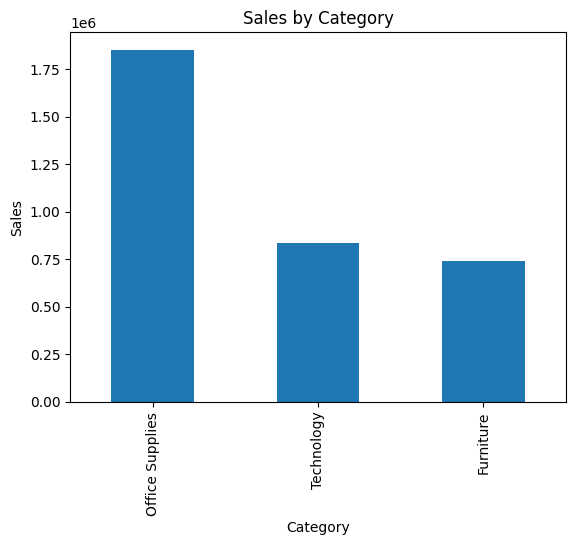

In [17]:
sales_category.plot( kind='bar', title='Sales by Category' )

plt.xlabel('Category')
plt.ylabel('Sales')

**Sales by Region**

In [7]:
sales_region = ( df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

sales_region

Region
East       1809912.34
West        722125.47
Central     500037.76
South       391985.41
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales')

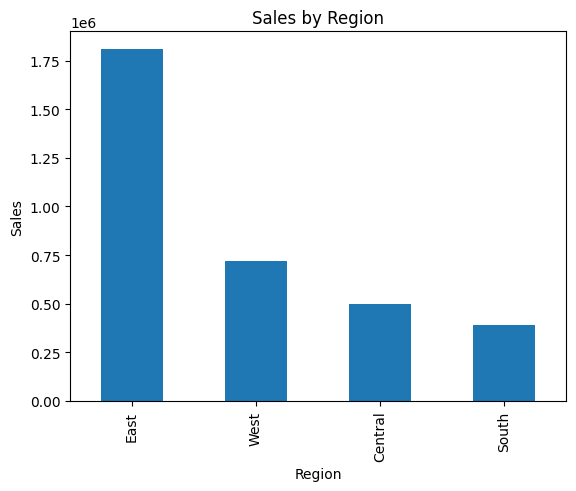

In [16]:
sales_region.plot( kind='bar', title='Sales by Region')

plt.xlabel('Region')
plt.ylabel('Sales')

**Sales over Time**

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [10]:
sales_time = ( df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum())

sales_time

Order Date
2014-01      14251.10
2014-02       4530.57
2014-03      55095.72
2014-04      28069.57
2014-05      23609.95
2014-06      35163.66
2014-07      33941.06
2014-08      28758.85
2014-09      81454.74
2014-10      31546.76
2014-11      79110.39
2014-12      66662.95
2015-01      18174.08
2015-02      12057.54
2015-03      38816.62
2015-04      33780.80
2015-05      30036.71
2015-06      24857.84
2015-07      28899.33
2015-08      37035.04
2015-09      64830.02
2015-10      31285.04
2015-11      75927.67
2015-12      76302.51
2016-01    1150754.50
2016-02      23111.52
2016-03      51570.07
2016-04      38752.41
2016-05      56710.39
2016-06      40438.38
2016-07      39297.66
2016-08      30840.06
2016-09      73856.51
2016-10      59663.59
2016-11      78904.29
2016-12      97105.72
2017-01      43673.21
2017-02      20342.98
2017-03      59296.16
2017-04      36335.41
2017-05      44242.14
2017-06      53126.61
2017-07      43486.03
2017-08      62800.56
2017-09      86841.52

Text(0, 0.5, 'Sales')

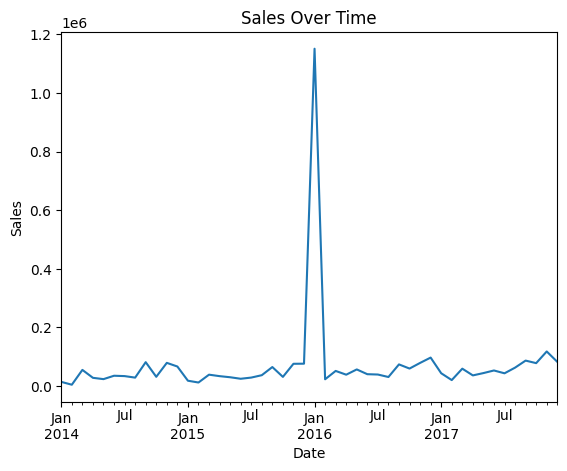

In [15]:
sales_time.plot( kind='line',title='Sales Over Time')

plt.xlabel('Date')
plt.ylabel('Sales')

**Top 10 Products by Sales**

In [19]:
top_products = ( df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10))

top_products

Product Name
4009 Highlighters                                                              1131924.00
Canon Imageclass 2200 Advanced Copier                                            61599.83
Fellowes Pb500 Electric Punch Plastic Comb Binding Machine With Manual Bind      27453.38
Cisco Telepresence System Ex90 Videoconferencing Unit                            22638.48
Hon 5400 Series Task Chairs For Big And Tall                                     21870.57
Gbc Docubind Tl300 Electric Binding System                                       19823.47
Gbc Ibimaster 500 Manual Proclick Binding System                                 19024.50
Hp Designjet T520 Inkjet Large Format Printer - 24" Color                        18374.89
Gbc Docubind P400 Electric Binding System                                        17965.07
Hewlett Packard Laserjet 3310 Copier                                             17399.70
Name: Sales, dtype: float64

Text(0, 0.5, 'Product')

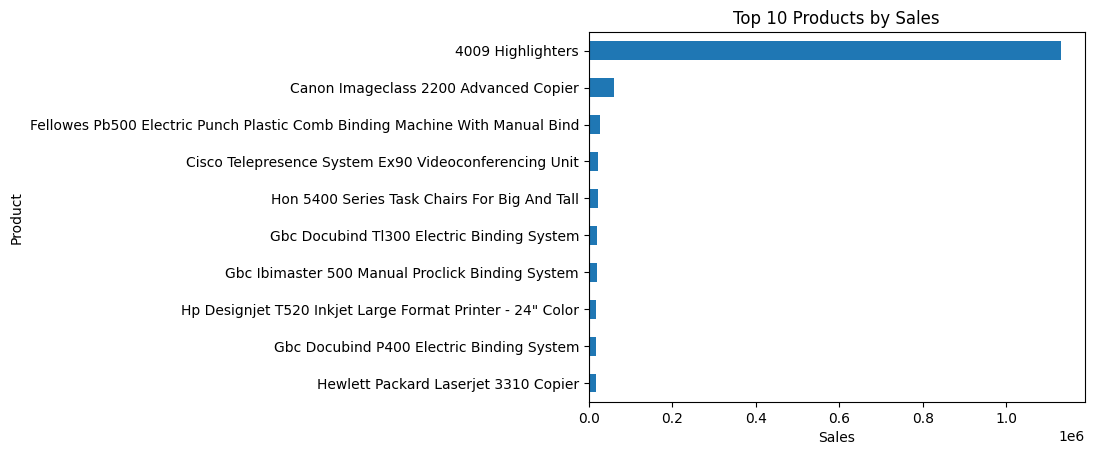

In [20]:
top_products.sort_values().plot( kind='barh', title='Top 10 Products by Sales')

plt.xlabel('Sales')
plt.ylabel('Product')

**Sales by Segment**

In [21]:
sales_segment = ( df.groupby('Segment')['Sales'].sum().sort_values(ascending=False) )

sales_segment


Segment
Corporate      1836783.06
Consumer       1157797.46
Home Office     429480.46
Name: Sales, dtype: float64

Text(0, 0.5, 'Sales')

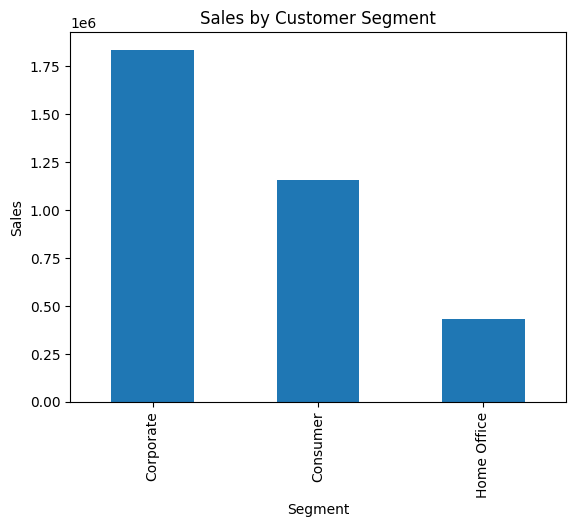

In [22]:
sales_segment.plot( kind='bar', title='Sales by Customer Segment' )

plt.xlabel('Segment')
plt.ylabel('Sales')


**Quantity vs Sales**

Text(0, 0.5, 'Sales')

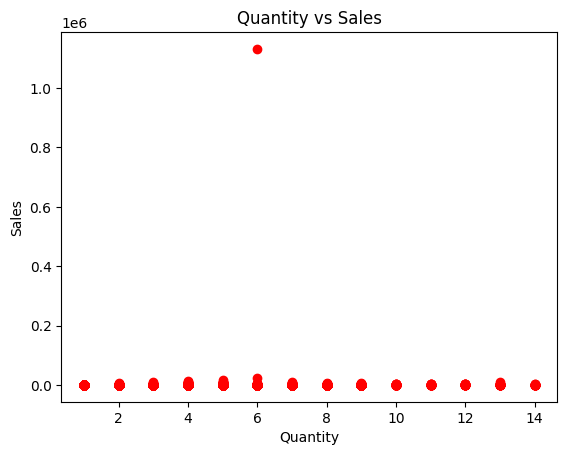

In [25]:
plt.scatter(df['Quantity'], df['Sales'] , c='red')
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')

In [28]:
profile = ProfileReport( df, title='Cleaned Store Data Profiling Report', explorative=True )

profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:01<00:00, 12.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [29]:
profile.to_file('../data/processed/profiling_cleaned.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]